In [5]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from typing import TypedDict, Optional

# ---------- State ----------
class State(TypedDict, total=False):
    input: str
    stored: str
    fetched: str
    requested: str


# ---------- Parallel Tasks ----------
def store_data(state: State):
    return {"stored": f"stored({state['input']})"}

def fetch_something(state: State):
    return {"fetched": "fetched(resource)"}

def request_something(state: State):
    return {"requested": "requested(api)"}


# ---------- Fan-out Node ----------
def fan_out(state: State):
    """
    Launch 3 nodes in parallel. Execution will pause
    until ALL three complete.
    """
    return [
        Send("store_data", state),
        Send("fetch_something", state),
        Send("request_something", state),
    ]


# ---------- Join Node ----------
def after_all(state: State):
    # All 3 outputs are now guaranteed to exist
    print("STATE AT JOIN:", state)
    return state


# ---------- Build Graph ----------
graph = StateGraph(State)

graph.add_node("fan_out", fan_out)
graph.add_node("store_data", store_data)
graph.add_node("fetch_something", fetch_something)
graph.add_node("request_something", request_something)
graph.add_node("after_all", after_all)

graph.add_edge(START, "fan_out")
graph.add_edge("fan_out", "after_all")   # runs AFTER all 3 complete
graph.add_edge("fan_out", "store_data")
graph.add_edge("fan_out", "fetch_something")
graph.add_edge("fan_out", "request_something")
graph.add_edge("after_all", END)

app = graph.compile()


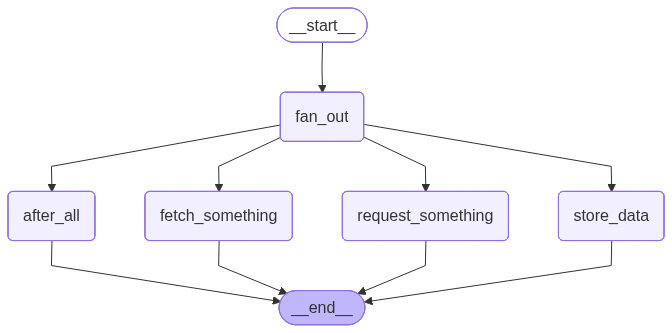

In [6]:
# Show the agent
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

